In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
import seaborn as sns

In [30]:
df = pd.read_csv('/Users/elzaniyazbekova/Desktop/MLLM/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [31]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

# Task 1: Data Integrity Check


In [32]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [33]:
(df[df['Torque [Nm]']<0])

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF


In [34]:
df[(df["Air temperature [K]"] < df["Air temperature [K]"].min()) | (df["Air temperature [K]"] > df["Air temperature [K]"].max())]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF


In [35]:
df[(df["Process temperature [K]"] < df["Process temperature [K]"].min()) | (df["Process temperature [K]"] > df["Process temperature [K]"].max())]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF


In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

f = (df["Machine failure"] == 1) & ((df["TWF"] == 0) & (df["HDF"] == 0) & (df["PWF"] == 0) & (df["OSF"] == 0) & (df["RNF"] == 0))
no_f = (df["Machine failure"] == 0) & ((df["TWF"] == 1) | (df["HDF"] == 1) | (df["PWF"] == 1) | (df["OSF"] == 1) | (df["RNF"] == 1))
print(no_f.sum())


18


In [38]:
df[(df["Machine failure"] == 1) & ((df["TWF"] == 0) & (df["HDF"] == 0) & (df["PWF"] == 0) & (df["OSF"] == 0) & (df["RNF"] == 0))]


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
1437,1438,H30851,H,298.8,309.9,1439,45.2,40,1,0,0,0,0,0
2749,2750,M17609,M,299.7,309.2,1685,28.9,179,1,0,0,0,0,0
4044,4045,M18904,M,301.9,310.9,1419,47.7,20,1,0,0,0,0,0
4684,4685,M19544,M,303.6,311.8,1421,44.8,101,1,0,0,0,0,0
5536,5537,M20396,M,302.3,311.8,1363,54.0,119,1,0,0,0,0,0
5941,5942,L53121,L,300.6,310.7,1438,48.5,78,1,0,0,0,0,0
6478,6479,L53658,L,300.5,309.8,1663,29.1,145,1,0,0,0,0,0
8506,8507,L55686,L,298.4,309.6,1710,27.3,163,1,0,0,0,0,0
9015,9016,L56195,L,297.2,308.1,1431,49.7,210,1,0,0,0,0,0


### If this data feeds a real-time control system, what risks exist?


* No missing values
* The 9 failures without a root cause are a blind spot
* Class imbalance of about 3.4% can cause the model to miss failures
* No negative torque, no negative speed, no negative tool wear, and process temperature is never lower than air temperature
* Failures can happen from multiple factors, and model may fail to detect entering red zone
*  Any  "early-warning" trend claim must be validated once real time-series telemetry is
  available

# PHASE 2 — Sensor Behavior Analysis

In [39]:
numeric_features = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

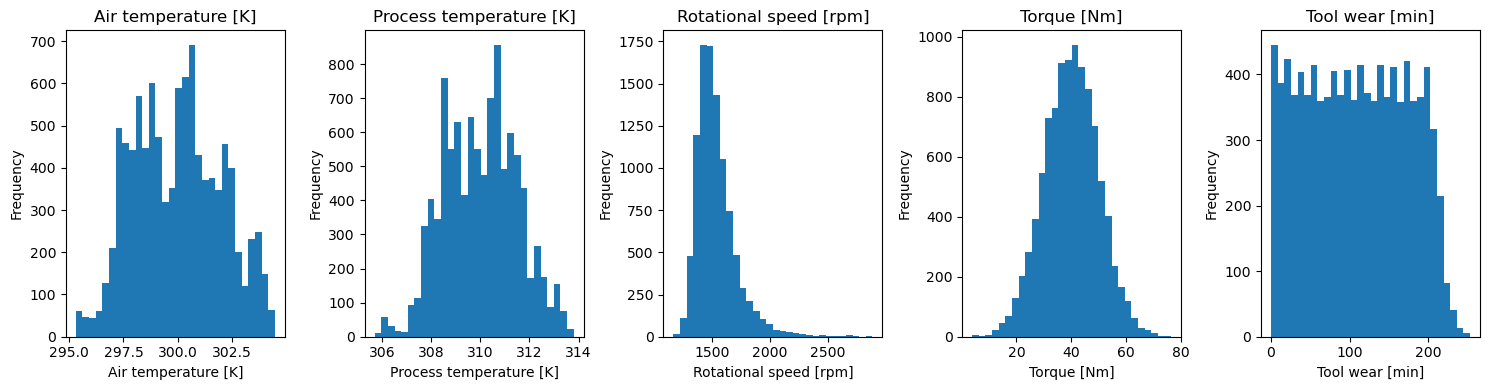

In [40]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

plt.figure(figsize=(15, 4))

for i, feature in enumerate(features, 1):
    plt.subplot(1, 5, i)
    plt.hist(df[feature], bins=30)
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [41]:
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1 
std = df[numeric_features].std()
result = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "Std": std
})
mean = df[numeric_features].mean()
median = df[numeric_features].median()
result

,Q1,Q3,IQR,Std
Air temperature [K],298.3,301.5,3.2,2.000259
Process temperature [K],308.8,311.1,2.3,1.483734
Rotational speed [rpm],1423.0,1612.0,189.0,179.284096
Torque [Nm],33.2,46.8,13.6,9.968934
Tool wear [min],53.0,162.0,109.0,63.654147


In [42]:
comparison = df.groupby('Machine failure')[numeric_features].mean()
extreme_zones = df[df['Machine failure'] == 0][numeric_features].quantile(0.95)
print(extreme_zones)

Air temperature [K]         303.5
Process temperature [K]     312.5
Rotational speed [rpm]     1863.0
Torque [Nm]                  54.8
Tool wear [min]             204.0
Name: 0.95, dtype: float64


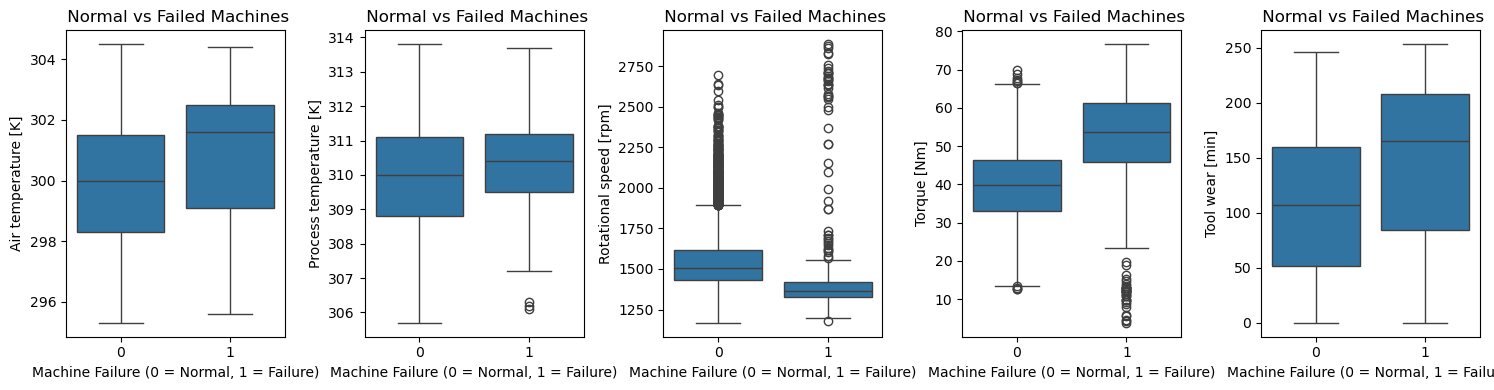

In [43]:
plt.figure(figsize=(15, 4))

for i, feature in enumerate(features, 1):
    plt.subplot(1, len(features), i)
    
    sns.boxplot(data=df, x="Machine failure", y=feature)
    plt.title(" Normal vs Failed Machines")
    plt.xlabel("Machine Failure (0 = Normal, 1 = Failure)")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()


| Sensor | Behavior before/at failure | Early-warning signal? |
|---|---|---|
| Torque [Nm] |Higher mean and wider spread in failed machines | **Strong** |
| Tool wear [min] | Higher mean in failed machines and a heavier right tail | **Strong**, consistent  failure |
| Rotational speed [rpm] | Lower mean in failed machines, wider spread (both very low and very high speeds appear) |  useful mainly in combination with torque (power ≈ speed × torque) |
| Process temperature [K] |Higher in failed machines | Weak  |
| Air temperature [K] | Almost the same distribution between normal and failed machines | **Not a signal** — mainly context/ambient information |

1. Which sensors behave differently before failure?
Torque and Tool wear behave differently the most. Rotational speed also shows some differences.

2. Which variables may be early warning signals?
Torque and Tool wear are the strongest early-warning signals. Rotational speed is a moderate signal, while temperature variables are weaker.

# PHASE 3 — Industrial Anomaly Detection

In [44]:
z_scores = pd.DataFrame()

for feature in numeric_features:
    m = df[feature].mean()
    s = df[feature].std()
    
    z_scores[feature] = (df[feature] - m) / s

z_scores.head()



,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,-0.952342,-0.947313,0.068182,0.282186,-1.695899
1,-0.902348,-0.879915,-0.729435,0.633276,-1.648769
2,-0.952342,-1.014710,-0.227438,0.944242,-1.617349
3,-0.902348,-0.947313,-0.589992,-0.048843,-1.585930
4,-0.902348,-0.879915,-0.729435,0.001313,-1.554510


In [45]:
anomalies = abs(z_scores) > 3

anomalies.sum()

Air temperature [K]          0
Process temperature [K]      0
Rotational speed [rpm]     164
Torque [Nm]                 25
Tool wear [min]              0
dtype: int64

In [46]:
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_anomaly = (
        (df[numeric_features] < lower_bound) |
        (df[numeric_features] > upper_bound)
    )
print(iqr_anomaly.sum())

Air temperature [K]          0
Process temperature [K]      0
Rotational speed [rpm]     418
Torque [Nm]                 69
Tool wear [min]              0
dtype: int64


In [47]:
anomaly_table = pd.DataFrame({

    "Feature": numeric_features,

    "Z-score anomalies": anomalies.sum().values,

    "IQR anomalies": iqr_anomaly.sum().values

})

print(anomaly_table)

                   Feature  Z-score anomalies  IQR anomalies
0      Air temperature [K]                  0              0
1  Process temperature [K]                  0              0
2   Rotational speed [rpm]                164            418
3              Torque [Nm]                 25             69
4          Tool wear [min]                  0              0


1. Are anomalies noise or early breakdown signals?
They are mostly early breakdown signals, not noise. Anomalies in torque, tool wear, and rotational speed are strongly related to machine failures.

2. Should we remove them or mark them as risk indicators?
They should be marked as risk indicators, not removed. Removing them could hide important failure patterns and make the model worse at detecting failures.

# PHASE 4 — Risk Segmentation (Business-Oriented)


In [48]:
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

def tool_wear_zone(x):
    if x <= 100:
        return 'Normal'
    elif x <= 200:
        return 'Maintenance soon'
    else:
        return 'Critical'

def temp_diff_zone(x):
    if x <= 8.6:
        return 'Stable'
    elif x <= 11.3:
        return 'Warning'
    else:
        return 'Overheating risk'

df['Tool_Wear_Zone'] = df['Tool wear [min]'].apply(tool_wear_zone)
df['Temp_Diff_Zone'] = df['Temp_diff'].apply(temp_diff_zone)


tool_wear_stats = df.groupby('Tool_Wear_Zone')['Machine failure'].agg(['count', 'mean'])
tool_wear_stats.columns = ['Count', 'Failure Rate']

temp_stats = df.groupby('Temp_Diff_Zone')['Machine failure'].agg(['count', 'mean'])
temp_stats.columns = ['Count', 'Failure Rate']
print(tool_wear_stats)

print(temp_stats)

                  Count  Failure Rate
Tool_Wear_Zone                       
Critical            762      0.154856
Maintenance soon   4571      0.025377
Normal             4667      0.022498
                  Count  Failure Rate
Temp_Diff_Zone                       
Overheating risk   1097      0.019143
Stable              720      0.175000
Warning            8183      0.023463


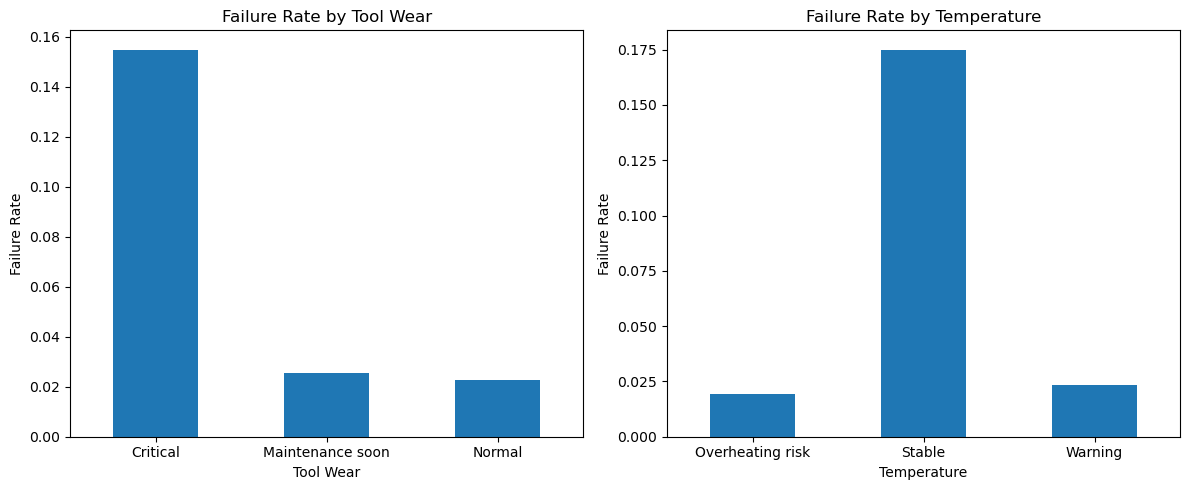

In [102]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
tool_wear_stats['Failure Rate'].plot(kind='bar')
plt.title('Failure Rate by Tool Wear')
plt.xlabel('Tool Wear')
plt.ylabel('Failure Rate')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
temp_stats['Failure Rate'].plot(kind='bar')
plt.title('Failure Rate by Temperature')
plt.xlabel('Temperature')
plt.ylabel('Failure Rate')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Does risk segmentation meaningfully separate failure probability?

Yes. Tool Wear shows a clear increase in failure rate from Normal → Maintenance soon → Critical, so it is a strong risk indicator.

Temperature Difference shows a smaller difference, so it is a secondary risk factor. It works better when combined with Tool Wear and Torque.

# PHASE 5 — Data Preparation for Production


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler_std = StandardScaler()
df[numeric_features] = scaler_std.fit_transform(df[numeric_features])

StandardScaler standardizes numerical features so that the mean is 0 and the standard deviation is 1. Anomalies found in Phase 3 are meaningful failure signals. StandardScaler keeps these extreme values, while Min-Max scaling can be strongly affected by them.

In [ ]:
imbalance = df['Machine failure'].value_counts(normalize=True)
print(imbalance)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


In [105]:
sample_30 = df.sample(frac=0.30, random_state=42)

In [107]:
full_failure_rate = df["Machine failure"].mean() * 100
sample_failure_rate = sample_30["Machine failure"].mean() * 100

print("Full Dataset")
print("Records:", len(df))
print("Failure Rate:", round(full_failure_rate, 2), "%")

print("\n30% Sample")
print("Records:", len(sample_30))
print("Failure Rate:", round(sample_failure_rate, 2), "%")

Full Dataset
Records: 10000
Failure Rate: 3.39 %

30% Sample
Records: 3000
Failure Rate: 3.1 %



* Only ~3.4% of records are failures, so accuracy can be misleading. Use precision, recall, F1-score, and PR-AUC.
*  A random 30% sample may contain too few or too many failures.
*  Machine types L, M, and H are not equally distributed, so the model may depend too much on machine type.
* The dataset represents one group of machines and may not work well for other machines or conditions.
*  RNF can sometimes appear without a real failure, which can add noise to the model.
*  9 failures have no assigned failure mode, so their cause cannot be properly learned.
*  Scaling should be fitted only on the training data, not on the whole dataset.